# 5 Volumetric 3D Arena


In [12]:
!pip install -q torch numpy matplotlib
!pip install -q git+https://github.com/jacobsvennevik/MADE.git

In [13]:
import os
import sys
import time
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import torch

sys.path.insert(0, '/workspace/CAN_Path_Integration_3D_model')
#sys.path.insert(0, os.path.abspath("../.."))

from experiments.arena_3d import Arena3DExperiment, Arena3DConfig 
from config import RunConfig, NetworkConfig, ExperimentConfig, world_to_flat_bins_3d
from model.metrics import wrapped_angle_diff
from analysis.scoring import scoring_input_from_npz, score_run, activity_rate_map, run_3d_online, score_3d_from_map, run_and_score_3d
from analysis.prototypes import reference_scores
from model.plane_estimation import angular_error_s2, plot_bingham_convergence
from model.plane_estimation import plot_bingham_convergence
from pi_drift_diagnostics import zero_velocity_diffusion, path_normalised_error
         


In [14]:
# config + experiment — n=64 sheet (2π/64); n comes from the QAN
# 5.7M steps ≈ 95% arena coverage at omega_std=0.03, speed 0.002; screen stays short
N_STEPS = 5_700_000
GRID_SPACING = 0.5
RATEMAP_BINS = 20
g_vec = np.array([0., 0., -9.81])

SPACING          = 2.0 * np.pi / 64
LAMBDA_NET       = 1.0        # ~10.2 cells/period at n=64
RATIO            = 1.05
ALPHA            = 0.15       # loop gain ~1.7 at this lambda and n
B                = 1.0
OFFSET_MAGNITUDE = 0.073
DT               = 0.25
SNAPSHOT_STRIDE  = 50_000     # default 100 OOMs at this sheet size, T=5.7M
DISPLAY_STRIDE   = 2_000

cfg = RunConfig(
    network=NetworkConfig(
        spacing=SPACING,
        dim=3,
        lambda_net=LAMBDA_NET,
        ratio=RATIO,
        alpha=ALPHA,
        b=B,
        offset_magnitude=OFFSET_MAGNITUDE,
        dt=DT,
        velocity_gain=B * 5.0,  # seed; overwritten with B*tau after the QAN is built
        build_connectivity=False,
    ),
    experiment=Arena3DConfig(
        n_steps=N_STEPS,
        grid_spacing=GRID_SPACING,
        ratemap_bins=RATEMAP_BINS,
    ),
)
exp = Arena3DExperiment(cfg, record=False)
TAU = float(exp.qan.cans[0].tau)
N = exp.qan.cans[0].nx(0)
exp.qan.velocity_gain = B * TAU
print(f"n {N}/axis | τ {TAU} | λ_net {LAMBDA_NET} ({LAMBDA_NET * N / (2*np.pi):.1f} cells) | "
      f"δ {OFFSET_MAGNITUDE} | α {ALPHA} | vg seed {exp.qan.velocity_gain:.4f}")
_omega = float(cfg.experiment.omega_std)
_tau_h = 2.0 / _omega**2
print(f"θ̇ {cfg.experiment.target_speed_rad_per_time}  "
      f"ρ={cfg.experiment.target_speed_rad_per_time * TAU / OFFSET_MAGNITUDE:.3f}  "
      f"δ/λ={OFFSET_MAGNITUDE / LAMBDA_NET:.3f}  "
      f"cells/period {LAMBDA_NET / SPACING:.1f}  "
      f"omega_std {_omega} rad·time^(−1/2)  τ_h={_tau_h:.0f} time units")
if abs(TAU - 5.0) > 0.05 or abs(cfg.experiment.target_speed_rad_per_time - 0.002) > 1e-6:
    print("WARNING: feasibility was checked at τ=5, θ̇=0.002; rerun that arithmetic")
 


[arena_3d] neurons 250,047 arena 2.0 m | grid_spacing 0.5 m | tilings 4.00


## Pre-flight

Do not start the 5.7M walk until this cell is green: θ₃ moves and the lattice is peaked. At the default snapshot stride of 100, `drive` allocates a huge host copy. Optuna screening stays on the short walks; this length is the winner ratemap run only.


In [ ]:
from model.network.torch_backend import TorchBackend
from model.network.calibration import fit_gain

world_pos, v_body, torus_gt = exp.generate_trajectory(n_steps=N_STEPS, seed=cfg.experiment.seed)
ptp = np.ptp(torus_gt, axis=0)
dmean = np.abs(np.diff(torus_gt, axis=0)).mean(axis=0)
print(f"torus_gt {torus_gt.shape}  ptp {ptp}  mean |Δθ| {dmean}")
if ptp[2] < 0.1:
    raise RuntimeError("θ₃ is pinned — do not launch")

SETTLE = int(np.ceil(10 / ((DT / TAU) * 0.2)))
backend = TorchBackend(exp.qan)
pk = backend.form_lattice(torus_gt[0], settle=SETTLE, min_peakedness=0.0)
period = float(backend.bump_period_cells())
kvec, kmag = backend.dominant_k()
print(f"form_lattice  peakedness {pk:.2f}  period {period:.2f} cells  "
      f"bumps/axis {N / period:.2f}")
print(f"dominant k {kvec}  |k|={kmag:.2f}  (want peakedness≥3)")
print(f"σ_i {backend.qan.kernel.sigma_i * N / (2*np.pi):.2f} cells  "
      f"λ_net {LAMBDA_NET * N / (2*np.pi):.1f} cells")
if pk < 3:
    raise RuntimeError("lattice pre-flight failed; do not launch")

S_latched = backend.S.clone()
n_bench = 500
t0 = time.time()
_ = backend.drive(torus_gt[:n_bench], snapshot_stride=SNAPSHOT_STRIDE,
                  display_stride=DISPLAY_STRIDE)
ms = (time.time() - t0) / n_bench * 1e3
backend.S = S_latched
print(f"benchmark {n_bench} steps: {ms:.1f} ms/step  "
      f"({N_STEPS/1e6:.1f}M ≈ {ms * N_STEPS / 3.6e6:.1f} h)  device {backend.device}")
if str(backend.device) == "mps":
    print("MPS runs the FFT on CPU; a Mac does not speed up the dominant cost. Prefer CUDA.")
if ms > 60:
    print(f"WARNING: >60 ms/step → {ms * N_STEPS / 3.6e6:.0f}+ hours on CPU for {N_STEPS/1e6:.1f}M steps")

vg, g = fit_gain(backend, torus_gt[0], cfg.experiment.target_speed_rad_per_time)
exp.qan.velocity_gain = float(vg) if np.isfinite(vg) else exp.qan.velocity_gain
print(f"fit_gain vg={vg}  residual g={g}")
if not np.isfinite(vg):
    raise RuntimeError("gain pre-flight failed; do not launch")

lam_lat = period * 2.0 * np.pi / N
frac = cfg.experiment.target_speed_rad_per_time * TAU / lam_lat
print(f"feasibility θ̇τ/λ_lattice={frac:.4f} (limit 0.015)")

vol = backend.current_volume()
fig, axes = plt.subplots(1, 3, figsize=(10, 3.2))
for ax, proj, lab in zip(axes, (vol.sum(axis=2), vol.sum(axis=1), vol.sum(axis=0)),
                         ("sum z (xy)", "sum y (xz)", "sum x (yz)")):
    ax.imshow(proj.T, origin="lower", cmap="inferno")
    ax.set_title(lab); ax.set_xticks([]); ax.set_yticks([])
fig.suptitle("Launch lattice after form_lattice")
fig.tight_layout(); plt.show()

del backend
print("pre-flight ok — launch the cell below")


In [15]:
print("Running ...")
t0 = time.time()
result = exp.run_experiment(g=g_vec)
elapsed_time = (time.time() - t0)/60
exp.save(result, f"workspace/runs/{cfg.experiment.run_name}.npz")
print(f"Saved runs/{cfg.experiment.run_name}.npz  ({elapsed_time}m)")

world_pos  = result.world_pos
torus_gt   = result.torus_gt
theta_hist = result.theta_hist
gap        = result.gap_hist
n_hat_hist = result.n_hat_hist
T          = cfg.experiment.n_steps

print(f"Filter gap  t=100: {gap[99]:.4f}  t=500: {gap[499]:.4f}  t={T}: {gap[-1]:.4f}")
print(f"n_hat at t={T}: {n_hat_hist[-1]}  (target [0, 0, 1] if the motion-reference plane stays horizontal)")
print(f"theta_3 decoded range: [{theta_hist[:, 2].min():.4f}, {theta_hist[:, 2].max():.4f}]  "
      f"(should span a range now; z is encoded on theta_3)")
print(f"MADE error  full: {result.mean_norm_error:.4f}  after t=200: {result.norm_error[200:].mean():.4f}")

Running ...
Saved runs/arena3d_T2100000_kap10.0_seed0_envSize2.0_gridSpacing0.5.npz  (27.813218251864114m)
Filter gap  t=100: 365.6788  t=500: 1152.4215  t=2100000: 1089.2634
n_hat at t=2100000: [0. 0. 1.]  (target [0, 0, 1] if the motion-reference plane stays horizontal)
theta_3 decoded range: [0.0000, 6.2832]  (should span a range now; z is encoded on theta_3)
MADE error  full: 0.0043  after t=200: 0.0043


/tmp/ipykernel_1186/2796094629.py:9: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()


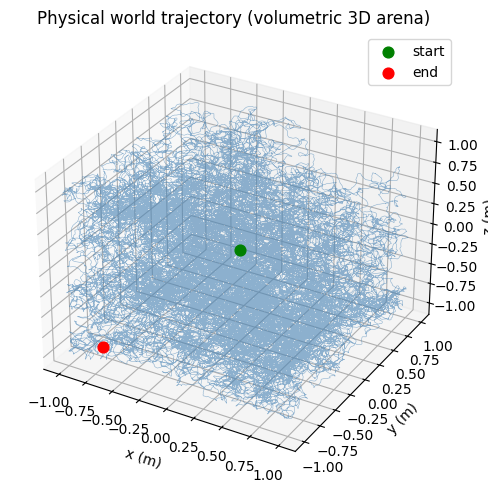

In [16]:
fig = plt.figure(figsize=(5.5, 5))
ax = fig.add_subplot(111, projection="3d")
ax.plot(world_pos[:, 0], world_pos[:, 1], world_pos[:, 2], lw=0.4, alpha=0.6, color="steelblue")
ax.scatter(*world_pos[0],  color="green", s=60, label="start")
ax.scatter(*world_pos[-1], color="red",   s=60, label="end")
ax.set_xlabel("x (m)"); ax.set_ylabel("y (m)"); ax.set_zlabel("z (m)")
ax.set_title("Physical world trajectory (volumetric 3D arena)")
ax.legend()
plt.tight_layout()
plt.show()

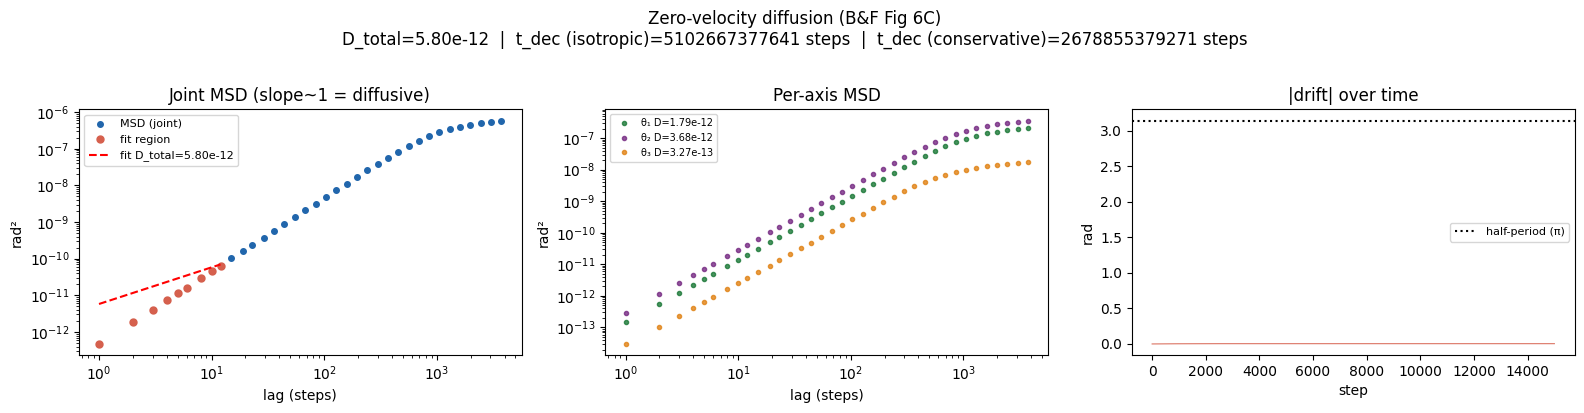

D_total      = 5.803e-12 rad²/step
D_per_axis   = [1.791e-12, 3.684e-12, 3.272e-13] rad²/step
t_decohere (isotropic)    = 5102667377641 steps
t_decohere (conservative) = 2678855379271 steps


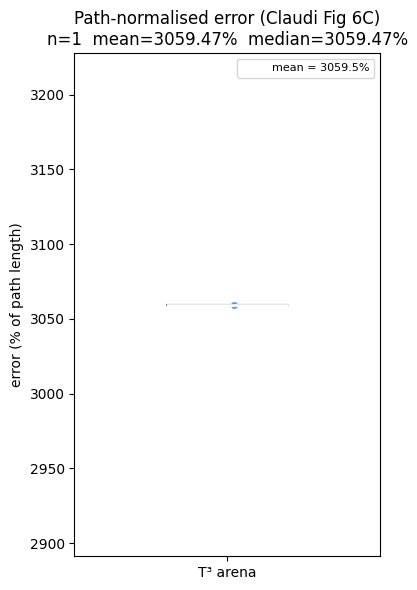

mean   = 3059.47%
median = 3059.47%
IQR    = [3059.47%, 3059.47%]


In [17]:
# B&F Fig 6C — how fast does the bump wander with no velocity input?
D_total, D_per_axis, t_dec_iso, t_dec_cons = zero_velocity_diffusion(exp, g_vec, n_steps=15000)
errors_pct = path_normalised_error(exp, g_vec, n_trials=1, n_steps=10_000)

In [18]:
ratemap_ndim = 3
RATEMAP_BINS = cfg.experiment.ratemap_bins   # e.g. 20
total_bins   = RATEMAP_BINS ** ratemap_ndim  # 20³ = 8000, used for allocate_ratemap

#pass per-axis bin count, no ndim kwarg
flat_indices_3d = world_to_flat_bins_3d(
    world_pos,
    cfg.experiment.env_size,
    RATEMAP_BINS,              # ← per-axis resolution, NOT total_bins
)

bk      = exp.last_integrator.backend
sub_idx = result.sub_idx                                  # the 300 neurons base.py drew
sub_t   = torch.tensor(sub_idx, dtype=torch.long, device=bk.device)

acc = bk.allocate_ratemap(total_bins, sub_t)              # (8000, 300), not (8000, 250047)
for t in range(len(torus_gt)):
    bk.reset(torus_gt[t], radius=0.25)
    bk.record_ratemap(acc, int(flat_indices_3d[t]), sub_t)

sums_or_3d, counts_or_3d = bk.ratemap_to_numpy(acc, RATEMAP_BINS, ndim=ratemap_ndim)
# → sums_or_3d: (20, 20, 20, N),  counts_or_3d: (20, 20, 20)


In [19]:
err = np.linalg.norm(wrapped_angle_diff(theta_hist, torus_gt), axis=1)
print("raw err  -> mean", err[1:].mean(), " final", err[-1], " max", err.max())
print("normed   -> ", (err[1:]/np.cumsum(np.linalg.norm(np.diff(world_pos,0),1)+1e-9)).mean())

raw err  -> mean 2.2647856904507577  final 3.4748427344123605  max 4.056625956652702
normed   ->  2.052985852381642e-06


In [20]:
def occ_report(tag, sums, counts):
    occ  = float((counts > 0).mean())
    span = np.ptp(sums.reshape(-1, sums.shape[-1]), axis=0)
    am   = span > 1e-3 * (span.max() + 1e-12)        # the active_mask rule
    flag = "OK" if occ >= 0.15 else "BELOW 15% -> chi NaN-filled -> reads 0"
    print(f"{tag}: occupancy={occ:.2%}  "
          f"unique_bins={(counts>0).sum():.0f}/{counts.size}  "
          f"active_cells={int(am.sum())}/{sums.shape[-1]}  | {flag}")

occ_report("oracle", sums_or_3d, counts_or_3d)                       # from cell 7
occ_report("real  ", result.ratemap_sums, result.ratemap_counts)    # from cell 4

oracle: occupancy=84.71%  unique_bins=6777/8000  active_cells=300/300  | OK
real  : occupancy=84.71%  unique_bins=6777/8000  active_cells=300/300  | OK


In [21]:
d = wrapped_angle_diff(theta_hist, torus_gt)            # (T,3) rad
nrm = np.linalg.norm(d, axis=1)
print(f"err norm -> mean {nrm[1:].mean():.3f}  final {nrm[-1]:.3f}  max {nrm.max():.3f}")
mae = np.abs(d)[1:].mean(0)
print(f"per-axis mean |err| -> x:{mae[0]:.3f}  y:{mae[1]:.3f}  z:{mae[2]:.3f} (rad)")
print(f"per-axis final|err| -> x:{abs(d[-1,0]):.3f}  y:{abs(d[-1,1]):.3f}  z:{abs(d[-1,2]):.3f}")

err norm -> mean 2.265  final 3.475  max 4.057
per-axis mean |err| -> x:0.832  y:1.783  z:0.881 (rad)
per-axis final|err| -> x:1.596  y:2.627  z:1.621


In [22]:
def _report_3d(tag, sums, counts, shuf_sums=None, active_mask=None):
    res = score_3d_from_map(sums, counts, shuf_sums=shuf_sums, active_mask=active_mask,
                            align=False, global_order=True)
    if not res or res.get("chi") is None:
        print(f"{tag}: no scoreable cells"); return res
    go = res.get("go")
    if go is None:                       # low-occupancy NaN-fill branch drops 'go'
        print(f"{tag}: occ {res['occupancy']:.0%} reliable={res.get('reliable')} -> occupancy too low")
        return res
    grid_like = int((np.isfinite(go) & (go > 0)).sum())
    print(f"{tag}: occ {res['occupancy']:.0%} | grid_like(go) {grid_like}/{len(res['scored_idx'])} "
          f"| go median {np.nanmedian(go):.3f} max {np.nanmax(go):.3f}")
    return res
out_oracle_3d = _report_3d("oracle", sums_or_3d, counts_or_3d)
out_real_3d   = _report_3d("real  ", result.ratemap_sums, result.ratemap_counts,
                            shuf_sums=result.shuf_sums, active_mask=result.active_mask)
#print(f"The code took {elapsed_time:.4f} minutes to run.")   # see note below

oracle: occ 85% | grid_like(go) 0/300 | go median 0.000 max 0.000
real  : occ 85% | grid_like(go) 0/300 | go median 0.000 max 0.000


In [23]:
import numpy as np
bk = exp.last_integrator.backend

# (1) PLACEMENT: does reset->decode reproduce the target torus position?
rt = []
for t in [0, 100, 1000, 10_000, 100_000]:
    bk.reset(torus_gt[t], radius=0.25)
    dec = bk.decode_position_com(bk.S.mean(dim=0)).detach().cpu().numpy()
    rt.append(np.abs(wrapped_angle_diff(dec[None], torus_gt[t][None])[0]))
print("reset->decode round-trip |err| per axis (rad):",
      np.round(np.mean(rt, 0), 3), " (~0 = placement faithful)")

# (2) STRUCTURE: does the most-active oracle neuron have a periodic lattice?
rate = np.full(sums_or_3d.shape, np.nan); nz = counts_or_3d > 0
rate[nz] = sums_or_3d[nz] / counts_or_3d[nz][:, None]
k = int(np.nanargmax(np.nanmax(rate.reshape(-1, rate.shape[-1]), axis=0)))
m = rate[..., k]; thr = 0.5 * np.nanmax(m)
print(f"oracle neuron {k}: peak={np.nanmax(m):.3f}  bins>half-max={int(np.nansum(m>thr))}"
      f"  (a lattice = several separated clusters; ~5-bin spacing expected)")
print(np.array2string(np.nan_to_num(m[:, :, m.shape[2]//2]), precision=1, max_line_width=200))

reset->decode round-trip |err| per axis (rad): [0.001 0.001 0.   ]  (~0 = placement faithful)
oracle neuron 0: peak=1.000  bins>half-max=193  (a lattice = several separated clusters; ~5-bin spacing expected)
[[0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.3 0.  0.  0. ]
 [0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0. ]
 [0.  0.  0.  0.  0.  1.  0.8 0.  0.  0.  0.  0.  0.9 1.  0.  0.  0.  0.  0.  0.4]
 [0.  0.  0.  0.  0.  0.  0.4 0.  0.  0.  0.  0.  0.6 0.6 0.  0.  0.  0.  0.  0.2]
 [0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0. ]
 [0.  0.  0.  0.  0.  0.  0.  0.  0.1 0.8 0.  0.  0.  0.  0.  0.2 0.4 0.  0.  0. ]
 [0.  0.  0.  0.  0.  0.  0.  0.  0.5 1.  0.2 0.  0.  0.  0.  0.3 1.  0.4 0.  0. ]
 [0.  0.  0.  0.  0.  0.  0.  0.  0.  0.5 0.  0.  0.  0.  0.  0.  0.  0.  0.  0. ]
 [0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0. ]
 [0.  0.  0.  0.  0.  0.3 0.3 0.  0.  0.  0. 

In [ ]:
t0 = time.time()
print("Running RAM-only 3-D scoring ...")
occ_real = (result.ratemap_counts > 0).mean()
print(f"[real]   active neurons : {int(result.active_mask.sum())} / {len(result.active_mask)}")
print(f"[real]   occupancy      : {occ_real:.1%}")

res_real = score_3d_from_map(
    result.ratemap_sums, result.ratemap_counts,
    shuf_sums=result.shuf_sums,
    active_mask=result.active_mask,
    align=False,
)
scoring_time = (time.time() - t0) / 60        
res_oracle = score_3d_from_map(sums_or_3d, counts_or_3d, align=False)

def _chi_row(res):
    if not res or res.get("chi") is None:
        return (np.nan, np.nan, np.nan)
    return tuple(np.nanmedian(res["chi"], axis=1))   # rows: FCC, HCP, COL

fcc_r, hcp_r, col_r = _chi_row(res_real)
fcc_o, hcp_o, col_o = _chi_row(res_oracle)

print(f"\nchi (median over cells)    FCC      HCP      COL")
print(f"  real      {fcc_r:7.3f}  {hcp_r:7.3f}  {col_r:7.3f}")
print(f"  oracle    {fcc_o:7.3f}  {hcp_o:7.3f}  {col_o:7.3f}")
print(f"\nReal-run scoring took {scoring_time:.4f} min.")

Running RAM-only 3-D scoring ...
Active neurons : 300 / 300
Occupancy      : 84.7%
The code took 0.2101 minutes to run.
Active neurons : 300 / 300
Occupancy      : 84.7%  (6777/8000 voxels)


In [ ]:


if not res or res.get("chi") is None:
    print("No active neurons scored — check active_thresh or trajectory length.")
else:
    with np.errstate(all="ignore"):
        chi_max = np.nanmax(res["chi"], axis=0)
    print(f"chi_max   mean   : {np.nanmean(chi_max):.3f}  "
          f"median: {np.nanmedian(chi_max):.3f}  "
          f"max: {np.nanmax(chi_max):.3f}")
    print(f"sinfo     mean   : {res['sinfo'].mean():.3f} bits/sample  "
          f"(Z ≥ 2.58 is significant)")
    if res["sinfo_z"] is not None:
        sig = (res["sinfo_z"] >= 2.58).sum()
        print(f"sinfo_z   sig    : {sig} / {len(res['sinfo_z'])} cells  "
              f"(mean Z={res['sinfo_z'].mean():.2f})")
    else:
        print("sinfo_z: not available (re-run with n_shuffle > 0)")

chi_max   mean   : 0.000  median: 0.000  max: 0.000
sinfo     mean   : 0.533 bits/sample  (Z ≥ 2.58 is significant)
sinfo_z   sig    : 4 / 300 cells  (mean Z=-0.22)


Visualize the angular error of the bingham filter

(<Figure size 800x550 with 2 Axes>,
 array([<Axes: ylabel='angular error (deg)'>,
        <Axes: title={'center': 'Filter concentration (larger gap = more committed)'}, xlabel='time step', ylabel='certainty  z₂−z₁'>],
       dtype=object))

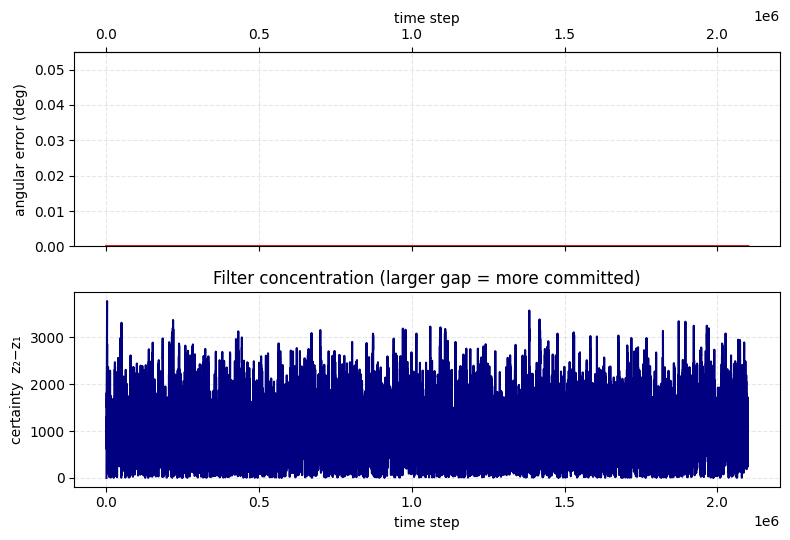

In [26]:
n_true = -g_vec / np.linalg.norm(g_vec)       #the correct gravity vector

plot_bingham_convergence(n_hat_hist, gap, n_true)